## 2.3 Backtest Engine

The objective of this section is to build a backtest engine that can process a generic sequence of trades using the fitted price impact models from Section 2.2.

In Section 2.2, we estimated stock-level impact coefficients $\hat{\lambda}_i$ and selected one half-life for each model. In this section, these fitted parameters are used to simulate how a trading schedule affects execution prices, positions, cash, impact costs, and P&L.

The implementation follows the same logic as the simulator used in the lectures. First, the model-implied impact of the public trading tape is removed from the observed mid-price path. This gives an impact-adjusted base price path. Then, our own strategy trades are applied to this base price path using the fitted impact model.

For the baseline implementation, each stock-day is treated independently. At the beginning of every trading day, we reset

$$
Q_0 = 0,
\qquad
X_0 = 0,
\qquad
I_0 = 0.
$$

Here:

- $Q_t$ is the position after trading at time $t$,
- $X_t$ is the cash account,
- $I_t$ is the temporary impact state.

Therefore, the baseline backtest does not carry inventory or impact overnight. This matches the baseline requirement for Section 2.3.

### Backtest dynamics

For one stock $i$ on one date $d$, let

$$
P_t^{obs}
$$

be the observed mid price at intraday time bin $t$. The public trading tape contains signed market trades

$$
q_t^{pub},
$$

while our strategy submits trades

$$
q_t^{my}.
$$

The first step is to remove the model-implied impact of public trades from the observed price path. Let $\widetilde I_t^{pub}$ denote the public-trade impact feature computed with $\lambda=1$. The fitted public impact state is then

$$
I_t^{pub}
=
\hat{\lambda}_i \widetilde I_t^{pub}.
$$

The impact-adjusted base price is

$$
P_t
=
P_t^{obs}
-
P_0^{obs} I_t^{pub}.
$$

This follows the lecture simulator idea: the public trading tape is used to estimate the impact already embedded in observed prices, and this impact is subtracted before applying our own strategy.

Next, the backtest applies our strategy trades to the adjusted price path $P_t$. The position evolves as

$$
Q_t
=
Q_{t-1} + q_t^{my}.
$$

For the OW model, the impact feature generated by our trades is

$$
\widetilde I_t^{my}
=
\rho_i \widetilde I_{t-1}^{my}
+
\sigma_i \frac{q_t^{my}}{ADV_i},
$$

where

$$
\rho_i = e^{-\beta_i \Delta t},
\qquad
\beta_i = \frac{\log 2}{\text{half-life}_i}.
$$

The fitted impact state is

$$
I_t^{my}
=
\hat{\lambda}_i \widetilde I_t^{my}.
$$

The execution price is then

$$
P_t^{exec}
=
P_t
+
P_0 I_t^{my}.
$$

This is consistent with the lecture code, where impact is added as an additive price move proportional to the initial price level.

The cash account evolves as

$$
X_t
=
X_{t-1}
-
q_t^{my} P_t^{exec}.
$$

The marked-to-market portfolio value is

$$
V_t
=
X_t + Q_t P_t.
$$

The final daily P&L is

$$
PnL_d = V_T.
$$

The direct impact cost is measured as

$$
\text{Impact Cost}
=
\sum_t q_t^{my}
\left(
P_t^{exec} - P_t
\right).
$$

This isolates the cost caused by our own temporary price impact.

### Inputs from previous sections

The backtest uses prepared data from Section 2.1 and fitted model outputs from Section 2.2.

From Section 2.1, we load:

- `test_px_df`: out-of-sample February mid-price panel,
- `test_traded_volume_df`: out-of-sample February public traded-volume panel,
- `scaling_df`: training-sample stock-level scaling variables,
- `train_stock_info_df`: training stock-day information, kept for diagnostics.

From Section 2.2, we load:

- `stock_results_df`: stock-level fitted impact model results for all models and half-lives,
- `best_df`: selected best half-life for each model based on in-sample $R^2$.

The February data is used only for out-of-sample backtesting. The fitted impact parameters and scaling variables are estimated from the January training period.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

import src.backtest_engine as backtest_engine

importlib.reload(backtest_engine)

from src.backtest_engine import *

In [2]:
# Outputs from 2.1

test_px_df = pd.read_csv("data/test_px_201902_20.csv")
test_px_df = test_px_df.set_index(["stock", "date"]).sort_index()

test_traded_volume_df = pd.read_csv("data/test_traded_volume_201902_20.csv")
test_traded_volume_df = test_traded_volume_df.set_index(["stock", "date"]).sort_index()

scaling_df = pd.read_csv("data/scaling_201901_20.csv")
scaling_df = scaling_df.set_index("stock").sort_index()

train_stock_info_df = pd.read_csv("data/train_stock_info_201901_20.csv")
train_stock_info_df = train_stock_info_df.set_index(["stock", "date"]).sort_index()

In [3]:
# Outputs from 2.2

stock_results_df = pd.read_csv(
    "data/impact_model_stock_results_201901_train_201902_test.csv"
)

best_df = pd.read_csv(
    "data/impact_model_best_by_is_201901_train_201902_test.csv"
)

### Selecting fitted model parameters

The stock-level results from Section 2.2 contain fitted parameters for several models and several half-lives. For the backtest, we first select one half-life per model using the `best_df` table.

For each model, we keep only the stock-level rows corresponding to the selected half-life. This gives one fitted parameter table per model:

$$
\hat{\lambda}_i^{OW},
\qquad
\hat{\lambda}_i^{AFS},
\qquad
\hat{\lambda}_i^{RF}.
$$

Each table has one row per stock and contains the fitted impact coefficient $\hat{\lambda}_i$ and the selected half-life.

These fitted tables are then passed into the backtest engine. The same February price data and the same strategy trades are used for each model, so differences in the results come from the impact model rather than from changing the trading schedule.

In [6]:
ow_fit_df = get_best_model_fit_df(stock_results_df, best_df, "ow")
afs_fit_df = get_best_model_fit_df(stock_results_df, best_df, "afs")
reduced_fit_df = get_best_model_fit_df(stock_results_df, best_df, "reduced_form")

### Trading schedules

### Trading schedules

The backtest engine is written so that the trading schedule is passed in as a full trade dataframe. This makes the simulator generic: the same backtest function can be used for TWAP trades, alpha-driven trades, or optimal trades in later sections.

The trade dataframe has the same index and columns as `test_px_df`:

- rows correspond to stock-days,
- columns correspond to intraday time bins,
- entries are signed trade sizes.

Positive values represent buys and negative values represent sells.

We construct two simple schedules.

The first is a one-way TWAP schedule. For each stock-day, the strategy buys a fixed fraction of the stock's average daily volume evenly throughout the day. If the participation rate is $\pi$, the target quantity is

$$
Q_i^{target}
=
\pi ADV_i.
$$

With $T$ intraday bins, the one-way TWAP trade is

$$
q_t^{my}
=
\frac{Q_i^{target}}{T},
\qquad
t=1,\dots,T.
$$

This schedule ends the day with a non-zero position, so its P&L is affected by the intraday price movement of the stock.

The second schedule is a round-trip TWAP. In this case, the strategy buys during the first half of the day and sells during the second half of the day:

$$
q_t^{my}
=
\begin{cases}
\frac{Q_i^{target}}{T_1}, & t \leq T_1, \\
-\frac{Q_i^{target}}{T - T_1}, & t > T_1,
\end{cases}
$$

where $T_1$ is the number of bins in the first half of the day.

This schedule ends with approximately zero final position, so it is a cleaner diagnostic for temporary impact and execution costs. In the baseline runs below, we use the round-trip TWAP schedule with

$$
\pi = 20\%.
$$

This means that the strategy buys approximately $20\%$ of ADV in the first half of the day and sells it back in the second half. Therefore, the total absolute traded volume is approximately $40\%$ of ADV.

In [5]:
# One way
twap_trades_df = make_twap_trade_df(
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    participation_rate=0.20
)

# Round trip
round_trip_trades_df = make_round_trip_twap_trade_df(
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    participation_rate=0.20
)


### Running the backtest across all stock-days

We now run the same round-trip TWAP trading schedule across all February stock-days for each fitted impact model.

The function `run_backtest_from_trade_df` takes the strategy trades as an input dataframe. This is important because later sections will replace the round-trip TWAP trades with alpha-driven or optimal trades, while keeping the same backtest engine.

For each stock-day, the backtest performs the following steps:

1. load the observed February mid-price path;
2. load the public traded-volume path;
3. remove the model-implied impact of public trades from observed prices;
4. apply the strategy trades to the impact-adjusted price path;
5. compute execution prices, positions, cash, P&L, and impact costs.

Each row of the resulting backtest table corresponds to one stock-day. The simulator records:

- daily P&L,
- impact cost,
- maximum absolute price impact,
- final position,
- total absolute traded volume,
- traded notional.

The same strategy trades and the same test set are used for all models, so the comparison isolates the effect of changing the impact model.

In [ ]:
# Round way TWAP
ow_backtest_df = run_backtest_from_trade_df(
    test_px_df=test_px_df,
    strategy_trades_df=round_trip_trades_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=ow_fit_df,
    model_type="ow",
    dt_seconds=10
)

ow_backtest_df = add_bps_metrics(ow_backtest_df)

In [9]:
afs_backtest_df = run_backtest_from_trade_df(
    test_px_df=test_px_df,
    strategy_trades_df=round_trip_trades_df,  # Change the trading strategy if needed
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=afs_fit_df,
    model_type="afs",
    dt_seconds=10
)

afs_backtest_df = add_bps_metrics(afs_backtest_df)

In [10]:
reduced_backtest_df = run_backtest_from_trade_df(
    test_px_df=test_px_df,
    strategy_trades_df=round_trip_trades_df,  # Change the trading strategy if needed
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=reduced_fit_df,
    model_type="reduced_form",
    dt_seconds=10
)

reduced_backtest_df = add_bps_metrics(reduced_backtest_df)

### Model comparison

To compare the fitted impact models, we combine the OW, AFS, and reduced-form backtest outputs into one table.

We report P&L and impact cost in basis points of traded notional:

$$
PnL_{bps}
=
10^4
\frac{PnL}{\text{traded notional}},
$$

and

$$
\text{Impact Cost}_{bps}
=
10^4
\frac{\text{Impact Cost}}{\text{traded notional}}.
$$

These normalized quantities make results comparable across stocks with different prices and trading volumes.

The comparison is not intended to evaluate alpha quality, because the round-trip TWAP schedule is only a diagnostic schedule. Instead, this section checks whether the backtest engine behaves sensibly under different fitted impact models and gives a first comparison of the impact costs implied by each model.

In [11]:
backtest_all_models_df = pd.concat(
    [ow_backtest_df, afs_backtest_df, reduced_backtest_df],
    ignore_index=True
)


In [12]:
model_comparison = (
    backtest_all_models_df
    .groupby("model_type")
    [["pnl_bps", "impact_cost_bps", "max_abs_impact"]]
    .agg(["mean", "median", "std", "min", "max"])
)

display(model_comparison)

pnl_bps                                               \
                  mean    median        std         min         max   
model_type                                                            
afs           3.350019  4.561111  24.715893 -132.007281  122.488852   
ow            2.762520  3.943063  24.699302 -132.133208  121.170213   
reduced_form  2.804241  4.063423  24.705897 -132.489430  121.697780   

             impact_cost_bps                                          \
                        mean    median       std       min       max   
model_type                                                             
afs                 0.182455  0.149116  0.113855  0.087785  0.631639   
ow                  0.759099  0.688321  0.213193  0.491971  1.444087   
reduced_form        0.725277  0.706956  0.183449  0.477716  1.280019   

             max_abs_impact                                          
                       mean    median       std       min       max  
model_type                                                           
afs                0.003416  0.001135  0.007653  0.000195  0.037077  
ow                 0.021303  0.006495  0.050763  0.001451  0.246433  
reduced_form       0.015906  0.004794  0.033760  0.001080  0.164430

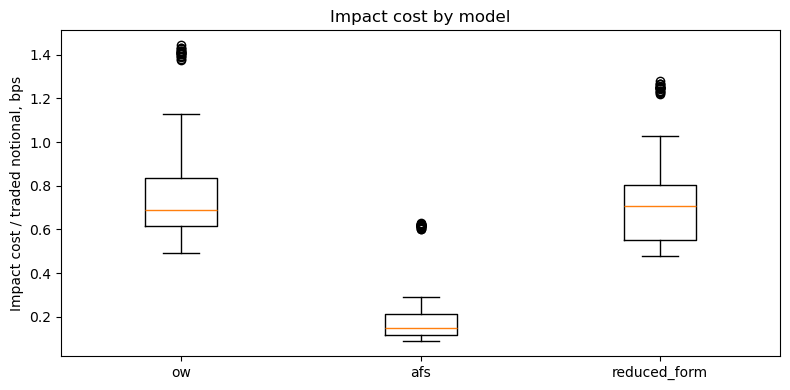

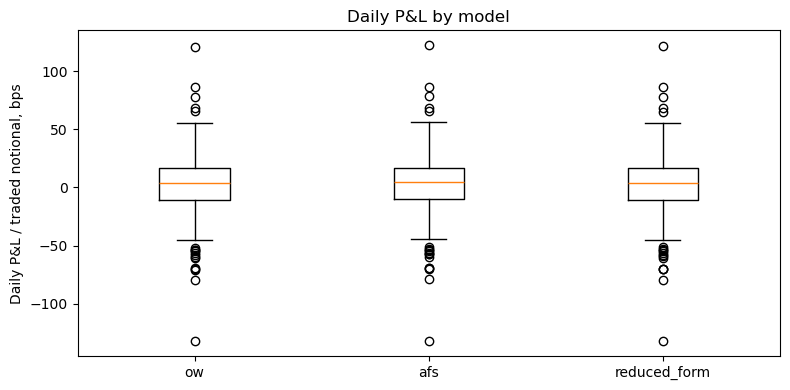

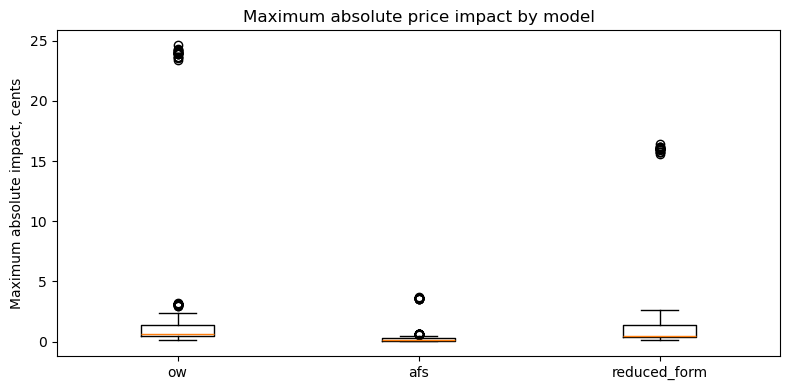

In [13]:
plot_model_comparison(backtest_all_models_df)

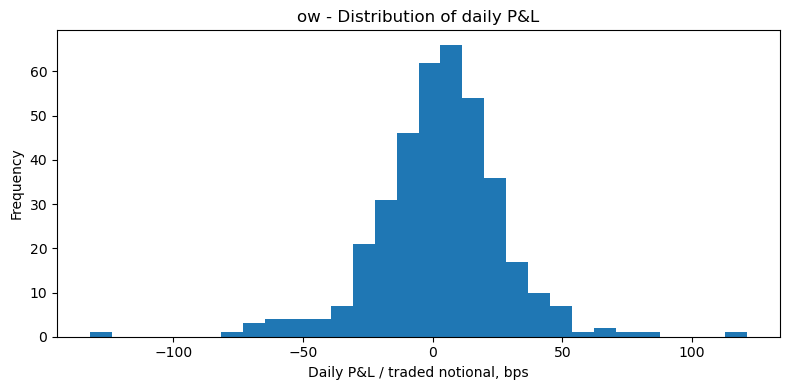

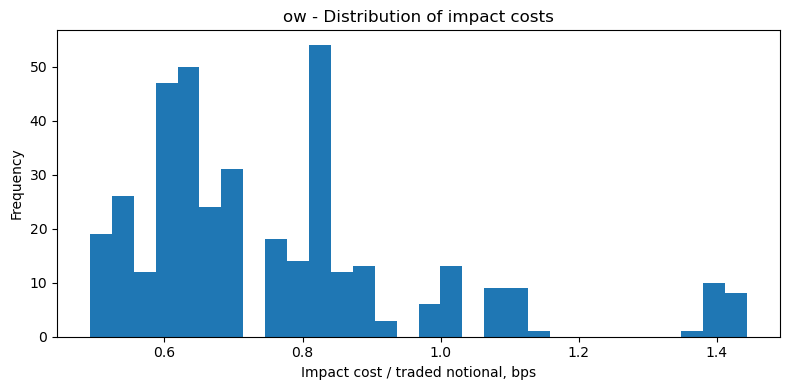

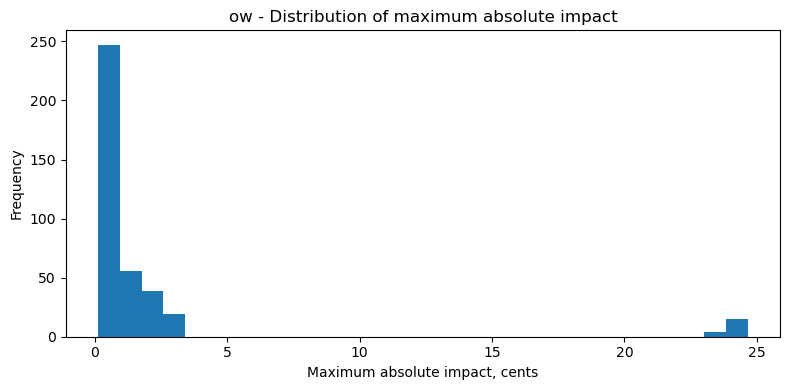

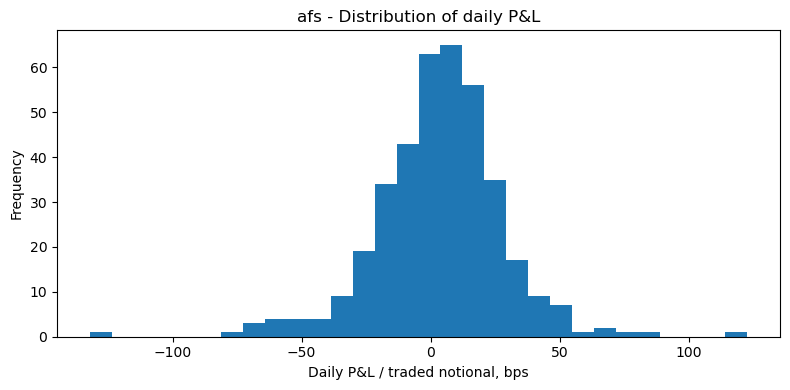

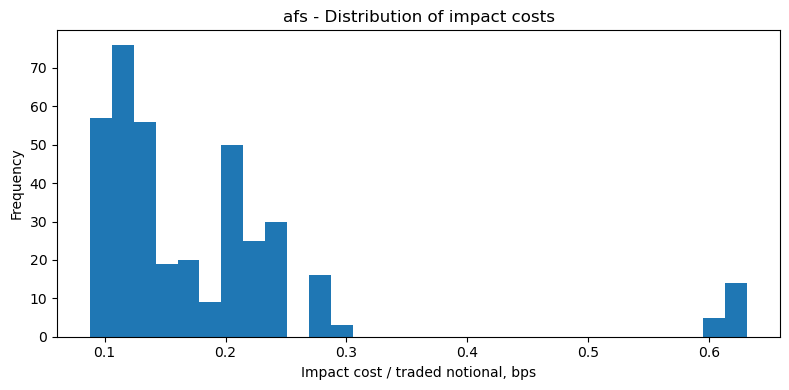

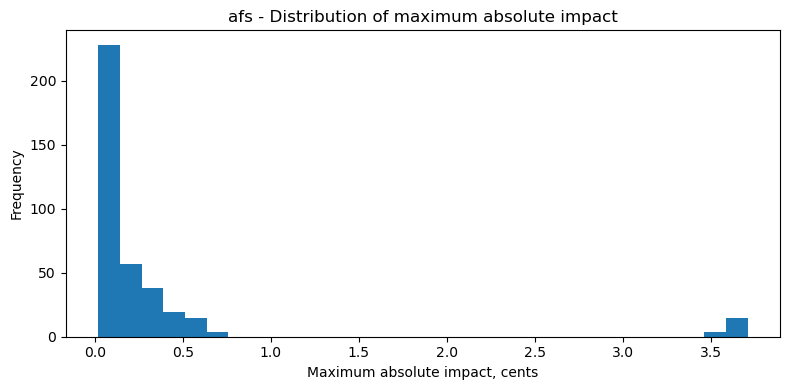

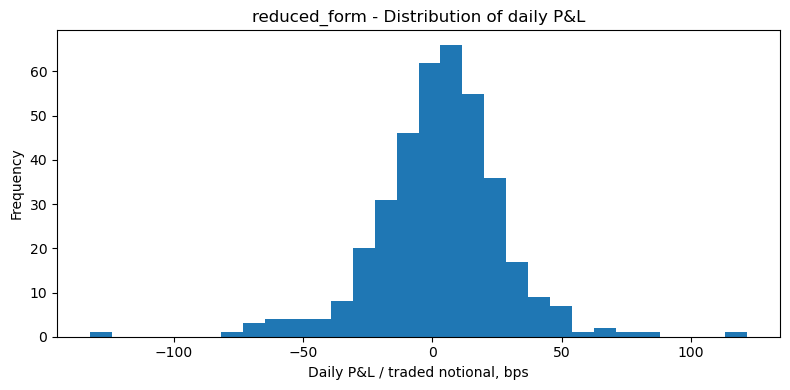

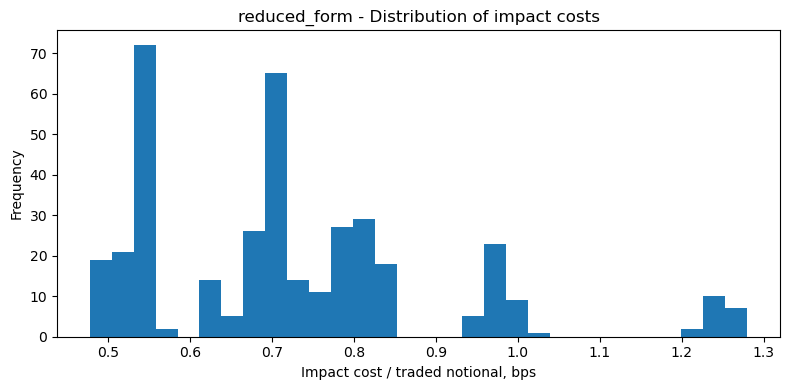

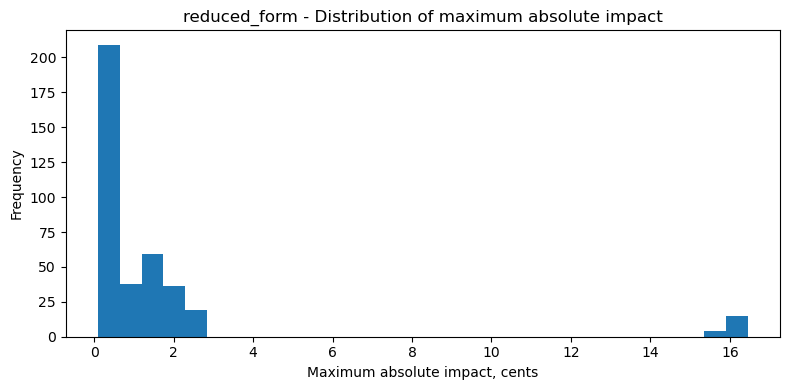

In [14]:
plot_backtest_summary(ow_backtest_df)
plot_backtest_summary(afs_backtest_df)
plot_backtest_summary(reduced_backtest_df)

### One-stock-day diagnostic

The full backtest summaries are computed across all stocks and all February dates. To visually inspect the mechanics of the simulator, we also examine one selected stock-day.

This diagnostic uses the same logic as the full backtest:

1. remove the model-implied public-trade impact from observed prices;
2. apply the selected strategy trades;
3. compute the resulting execution prices and own price impact.

The diagnostic plot shows:

- the impact-adjusted base price path,
- the execution-price path after applying our own trades,
- the temporary price impact created by our own trades.

For a round-trip TWAP, we expect own impact to increase during the buying phase and then decrease during the selling phase. Since the strategy ends with approximately zero final position, this plot is mainly used to check the mechanics of the simulator and the scale of temporary impact.

The main backtest results are the full stock-day summaries above.

In [15]:
fit_dfs = {
    "ow": ow_fit_df,
    "afs": afs_fit_df,
    "reduced_form": reduced_fit_df
}

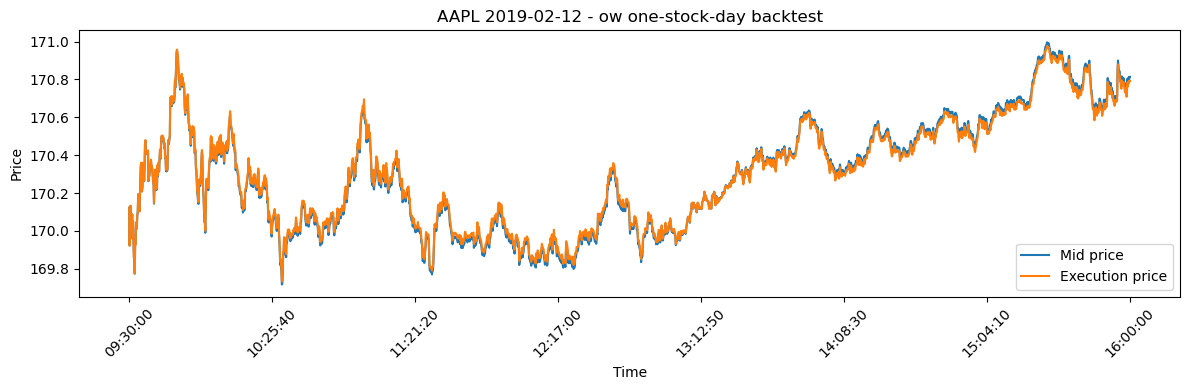

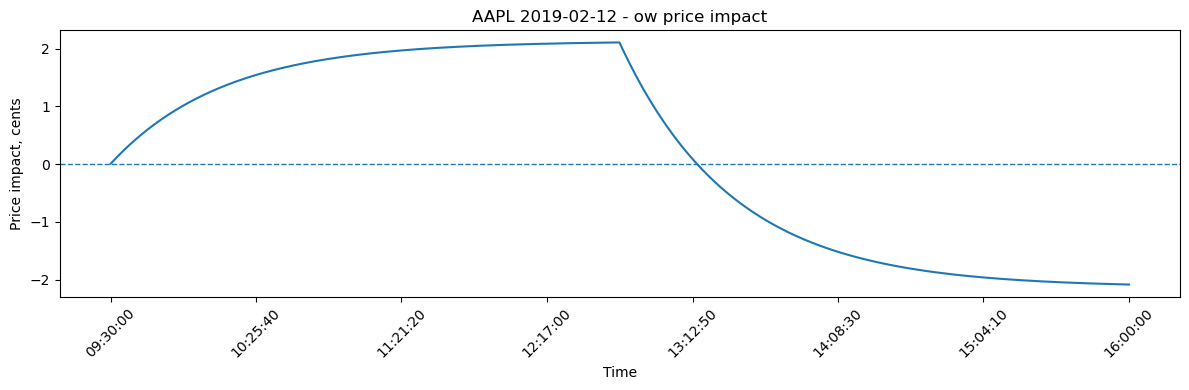

{'daily_pnl': np.float64(177581.87504673653),
 'impact_cost': np.float64(17015.420326521285),
 'max_abs_impact': 0.021075372871835543,
 'final_position': np.float64(1.8451487449056003e-08),
 'total_abs_traded': np.float64(1187385.1238095239),
 'net_traded': np.float64(0.0),
 'avg_price': np.float64(170.30027515422336),
 'traded_notional': np.float64(202212013.2987935),
 'model_type': 'ow',
 'stock': 'AAPL',
 'date': '2019-02-12',
 'lambda_hat': 9.791485378419305,
 'ADV': 2968462.8095238097,
 'sigma': 0.0002876491912289,
 'half_life_seconds': 1800.0}

In [17]:
stock = "AAPL"
date = test_px_df.loc[stock].index[0]

path_df, summary = run_one_stock_day_diagnostic(
    stock="AAPL",
    date="2019-02-12",
    model_type="ow",
    test_px_df=test_px_df,
    strategy_trades_df=round_trip_trades_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=10,
    plot=True
)

summary

### Saving backtest outputs

Finally, we save the full backtest outputs so they can be used in later sections for strategy evaluation, performance metrics, and sensitivity analysis.

The saved files contain the daily stock-day summaries for each model, as well as the combined model-comparison table. These outputs will be used later to compute portfolio-level performance metrics and to compare strategies under different model assumptions.

The saved backtest corresponds to the round-trip TWAP diagnostic strategy.

In [18]:
ow_backtest_df.to_csv(
    "data/backtest_ow_round_trip_twap_201902_20.csv",
    index=False
)

afs_backtest_df.to_csv(
    "data/backtest_afs_round_trip_twap_201902_20.csv",
    index=False
)

reduced_backtest_df.to_csv(
    "data/backtest_reduced_form_round_trip_twap_201902_20.csv",
    index=False
)

backtest_all_models_df.to_csv(
    "data/backtest_all_models_round_trip_twap_201902_20.csv",
    index=False
)